
This code aligns the column headers to match those of the signature matrix. It also scales the tissue proportions to 100% for the different tools that their output is sum to 1 (CIBERSORTx, MuSiC and BayesPrism).

BayesPrism contains pancreatic.pp.cell which is absent from the rest (not even as without the spaces). This cell type is included in the initial reference but was probably excluded because it contains only 2 cells in the whole reference.

In [4]:
import os
import glob
import pandas as pd

# Define the root directory
root_dir = 'COO-Decon-Pseudobulks'

# Optional: column renaming if needed

# Helper function to normalize row sums to 100
def normalize_to_100(df):
    sample_col = df.columns[0]
    columns_to_normalize = [col for col in df.columns if col != sample_col and pd.api.types.is_numeric_dtype(df[col])]
    df[columns_to_normalize] = df[columns_to_normalize].div(df[columns_to_normalize].sum(axis=1), axis=0) * 100
    return df

# Get all TSP-*Random_v2 subdirectories
subdirs = [d for d in glob.glob(os.path.join(root_dir, 'TSP-*-Random_v2')) if os.path.isdir(d)]

# Loop through each subdirectory
for subdir in subdirs:
    for file in os.listdir(subdir):
        if file.endswith('.txt') and not file.endswith('modified.txt'):
            file_path = os.path.join(subdir, file)

            try:
                df = pd.read_csv(file_path, sep="\t", index_col=0)

                if (
                    file.endswith('BayesPrism_renamed.txt') or
                    file.endswith('MuSiC.txt') or 
                    file.startswith('CIBERSORTx_Results') or
                    file.endswith('ReDeconv_results.txt')
                ):
                    if file.startswith('CIBERSORTx_Results'):
                        columns_to_exclude = ['P-value', 'Correlation', 'RMSE']
                        df = df.drop(columns=columns_to_exclude, errors='ignore')

                    df = normalize_to_100(df)
                if file.startswith('QP') or file.startswith('NNLS'):
                    columns_to_exclude = ['RMSE-Composition', 'r-Composition', 'RMSE-PredictedCounts', 'r-PredictedCounts']
                    df = df.drop(columns=columns_to_exclude, errors='ignore')

                # Round and save
                df = df.round(5)
                output_file_path = file_path.replace('.txt', '_modified.txt')
                df.to_csv(output_file_path, sep='\t')
                print(f"Processed and saved: {output_file_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")


Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42_filtered_Random_v2C_All-Counts_BayesPrism_renamed_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42-ReDeconv_Top3000_ReDeconv_results_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/nuSVR_Counts_TSP-HBA_Inner_1000_3000_10_v2C_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_modified.txt
Processed and saved: COO-Decon-Pseudobulks/TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_modified.txt
Processed and save

!python3 02_GroundTruth_Generation_New.py

In [5]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)

# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files ===
modified_files = sorted(glob("TSP-BDa_Inner*-Random_v2/*_modified.txt"))

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 21 prediction files.

Processing: TSP-BDa_Inner_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_modified.txt
Saved spillover: TSP-BDa_Inner_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_Spillover.txt

Processing: TSP-BDa_Inner_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-BDa_Inner_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Inner_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-BDa_Inner_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Inner_1000_3000_10-Random_v2/TSP-BDa_Inner_100each_seed42-ReDeconv_Top3000_ReDeconv_results_modified.txt
Saved spillover: TSP-BDa_Inner_1000_3000_10-Random_v2/TSP-BDa_Inner_100each_seed42-ReDeconv_Top3000_ReDeconv_results_Spillover.txt

Processing: TSP-BDa_Inner_1000_3000_10-Random_v2/TSP-BDa_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_modified.txt
Saved spillover: TSP-BDa_Inner_1000_3

In [6]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)

# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files ===
modified_files = sorted(glob("TSP-BDa_Outer*-Random_v2/*_modified.txt"))

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 21 prediction files.

Processing: TSP-BDa_Outer_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_modified.txt
Saved spillover: TSP-BDa_Outer_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_Spillover.txt

Processing: TSP-BDa_Outer_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-BDa_Outer_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Outer_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-BDa_Outer_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Outer_1000_3000_10-Random_v2/TSP-BDa_Outer_100each_seed42-ReDeconv_Top3000_ReDeconv_results_modified.txt
Saved spillover: TSP-BDa_Outer_1000_3000_10-Random_v2/TSP-BDa_Outer_100each_seed42-ReDeconv_Top3000_ReDeconv_results_Spillover.txt

Processing: TSP-BDa_Outer_1000_3000_10-Random_v2/TSP-BDa_Outer_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_modified.txt
Saved spillover: TSP-BDa_Outer_1000_3

In [7]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)

# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files ===
modified_files = sorted(glob("TSP-HBA*-Random_v2/*_modified.txt"))

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 21 prediction files.

Processing: TSP-HBA_Inner_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_modified.txt
Saved spillover: TSP-HBA_Inner_1000_3000_10-Random_v2/CIBERSORTx_Results_Merged_Spillover.txt

Processing: TSP-HBA_Inner_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-HBA_Inner_1000_3000_10-Random_v2/NNLS_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-HBA_Inner_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_modified.txt
Saved spillover: TSP-HBA_Inner_1000_3000_10-Random_v2/QP_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42-ReDeconv_Top3000_ReDeconv_results_modified.txt
Saved spillover: TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42-ReDeconv_Top3000_ReDeconv_results_Spillover.txt

Processing: TSP-HBA_Inner_1000_3000_10-Random_v2/TSP-HBA_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_modified.txt
Saved spillover: TSP-HBA_Inner_1000_3

In [8]:
# This script collects absolute differences (spillover) from all *_Spillover.txt files
# in the Random COO deconvolution results directories.
# It merges them into a dataframe with Sample, Method, Matrix, Tissue-specific Spillover values,
# and a new column 'Average' representing the mean spillover per sample.

import os
import pandas as pd
from glob import glob

# === CONFIGURATION ===
root_dir = 'COO-Decon-Pseudobulks'
method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

# === GATHER SPILLOVER FILES ===
random_dirs = sorted(glob(os.path.join(root_dir, 'TSP-*-Random_v2')))
spillover_data = []

# === PROCESS EACH SPILLOVER FILE ===
for dir_path in random_dirs:
    spillover_files = glob(os.path.join(dir_path, '*_Spillover.txt'))

    for file_path in spillover_files:
        try:
            # Load spillover values
            df = pd.read_csv(file_path, sep='\t', index_col=0)

            # Compute average spillover per sample
            df['Average'] = df.mean(axis=1)

            # Extract method name from file name
            filename = os.path.basename(file_path)
            raw_method = filename.replace('_Spillover.txt', '')
            method = next((m for m in method_map if m in raw_method), raw_method)

            # Extract matrix name from directory
            dir_name = os.path.basename(dir_path)
            matrix = dir_name.split('-')[1]

            # Add metadata
            df['Method'] = method
            df['Matrix'] = matrix
            df['Sample'] = df.index

            spillover_data.append(df.reset_index(drop=True))

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# === MERGE ALL RESULTS ===
merged_df = pd.concat(spillover_data, ignore_index=True)

# === SAVE TO FILE ===
output_path = 'merged_Results_Spillover_Random_v2C_New.txt'
merged_df.to_csv(output_path, sep='\t', index=False)
print(f"Saved merged spillover results: {output_path}")

Saved merged spillover results: merged_Results_Spillover_Random_v2C_New.txt


# This script collects average spillover (MAE) values from all *_Spillover.txt files
# in the Random COO results directories.
# It merges them into a dataframe with columns:
# Sample, Method, Matrix, and Average (mean spillover per sample).

import os
import pandas as pd
from glob import glob

# === CONFIGURATION ===
root_dir = 'COO-Decon-Pseudobulks'
method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

# === GATHER SPILLOVER FILES ===
random_dirs = sorted(glob(os.path.join(root_dir, 'TSP-*-Random_v2')))
spillover_data = []

# === PROCESS EACH SPILLOVER FILE ===
for dir_path in random_dirs:
    spillover_files = glob(os.path.join(dir_path, '*_Spillover.txt'))

    for file_path in spillover_files:
        try:
            # Load spillover values
            df = pd.read_csv(file_path, sep='\t', index_col=0)

            # Compute average spillover per sample
            avg_mae = df.mean(axis=1)

            # Extract method name from file name
            filename = os.path.basename(file_path)
            raw_method = filename.replace('_Spillover.txt', '')
            method = next((m for m in method_map if m in raw_method), raw_method)

            # Extract matrix name from directory
            dir_name = os.path.basename(dir_path)
            matrix = dir_name.split('-')[1]

            # Build clean dataframe
            clean_df = pd.DataFrame({
                'Sample': df.index,
                'Method': method,
                'Matrix': matrix,
                'Average_MAE': avg_mae.values
            })

            spillover_data.append(clean_df)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# === MERGE ALL RESULTS ===
merged_df = pd.concat(spillover_data, ignore_index=True)

# === SAVE TO FILE ===
output_path = 'merged_Results_Spillover_Random_v2C_New.txt'
merged_df.to_csv(output_path, sep='\t', index=False)
print(f"Saved merged spillover results: {output_path}")


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ------------------ Load CSV ------------------
file_path = 'merged_Results_Spillover_Random_v2C_New.txt'
df = pd.read_csv(file_path, sep='\t')

# ------------------ Pivot for heatmap ------------------
heatmap_data = pd.pivot_table(
    df,
    index='Matrix',
    columns='Method',
    values='Average_MAE',
    aggfunc='mean'
)

# ------------------ Extract Reference + MaxSig from Matrix ------------------
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))

annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))

def get_maxsig(x):
    parts = x.split('_')
    if len(parts) >= 2 and parts[-2].isdigit():
        return int(parts[-2])
    return -1

annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Sort rows by Reference then MaxSig ------------------
heatmap_data = (
    heatmap_data
    .assign(Reference=annotations['Reference'], MaxSig=annotations['MaxSig'])
    .sort_values(['Reference', 'MaxSig'])
    .drop(columns=['Reference', 'MaxSig'])
)

# Recompute annotations aligned with sorted index
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))
annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))
annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Reorder columns (fixed method order) ------------------
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
heatmap_data = heatmap_data.reindex(columns=method_order)

# ------------------ Palettes & LUTs ------------------
matrix_groups = sorted(annotations['Reference'].unique())
matrix_palette = sns.color_palette("Set2", n_colors=len(matrix_groups))
matrix_lut = dict(zip(matrix_groups, matrix_palette))

maxsig_keys = sorted(annotations['MaxSig'].unique())
maxsig_palette = sns.color_palette("Set3", n_colors=len(maxsig_keys))
maxsig_lut = dict(zip(maxsig_keys, maxsig_palette))

# Row colors only
row_colors = pd.DataFrame({
    'Reference': [matrix_lut[g] for g in annotations['Reference']],
    'MaxSig': [maxsig_lut[k] for k in annotations['MaxSig']]
}, index=annotations.index)[['Reference', 'MaxSig']]

# ------------------ Color scaling ------------------
vmin = np.nanmin(heatmap_data.to_numpy())
vmax = np.nanmax(heatmap_data.to_numpy())

# ------------------ Plot clustermap ------------------
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    cmap='viridis_r',
    figsize=(8, 5),
    annot=True, fmt=".2f",
    annot_kws={"size": 10},
    cbar_pos=None,
    linewidths=0,
    linecolor='white',
    dendrogram_ratio=(0.02, 0.02),
    vmin=vmin, vmax=vmax
)

# === Axis styling ===
# Remove row tick labels (hide matrix names)
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_yticklabels([])

# Add y-axis label
g.ax_heatmap.set_ylabel("Matrix", labelpad=30, fontsize=10)
g.ax_heatmap.yaxis.set_label_position("left")

# X-axis styling
g.ax_heatmap.set_xlabel("Deconvolution Tool", fontsize=10)
g.ax_heatmap.tick_params(
    axis='x', which='both', bottom=True, top=False, labelbottom=True,
    length=3, width=0.5, labelsize=10
)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=30, ha="right")

# === Colorbar ===
cbar_ax = g.fig.add_axes([0.88, 0.23, 0.03, 0.5])
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.ax.set_ylabel("Mean Absolute Error", fontsize=14, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=13, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

# === Legends ===
matrix_patches = [Patch(facecolor=matrix_lut[g], label=g) for g in matrix_groups]
maxsig_patches = [Patch(facecolor=maxsig_lut[k], label=str(k)) for k in maxsig_keys]

legend_ax1 = g.fig.add_axes([0.02, 0.65, 0.20, 0.20])
legend_ax1.axis('off')
legend_ax1.legend(handles=matrix_patches, title='Reference', loc='center', fontsize=10, title_fontsize=11)

legend_ax2 = g.fig.add_axes([0.02, 0.45, 0.20, 0.20])
legend_ax2.axis('off')
legend_ax2.legend(handles=maxsig_patches, title='Max Signatures', loc='center', fontsize=10, title_fontsize=11)

# Clean up row color axes
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])
g.ax_row_colors.set_xticklabels([])
g.ax_row_colors.set_yticklabels([])

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.25, right=0.85)
g.fig.savefig("Heatmap_Random_Spillover_WithReference_MaxSig.svg", bbox_inches="tight")
plt.close(g.fig)


/tmp/ipykernel_2365963/2903335597.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


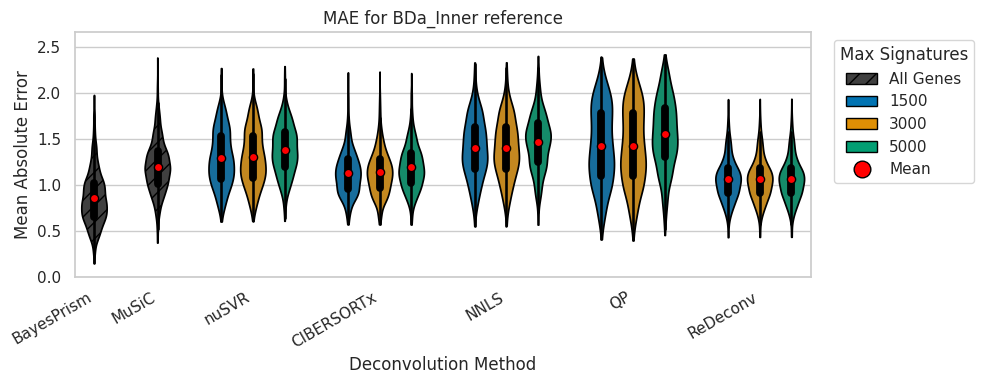

/tmp/ipykernel_2365963/2903335597.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


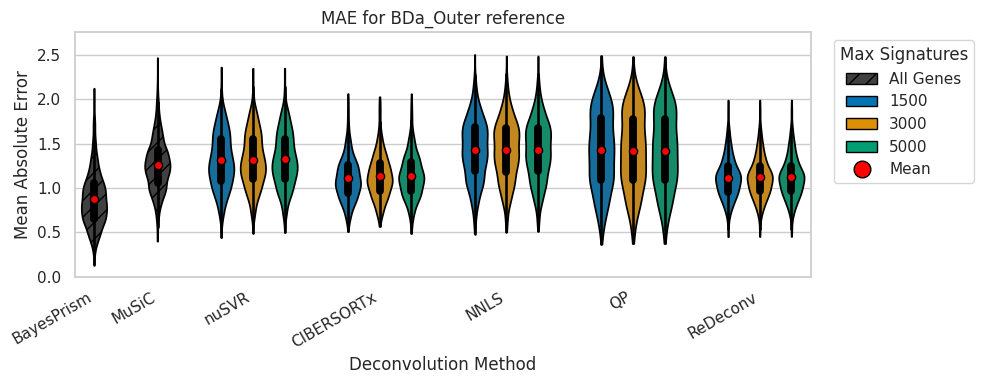

/tmp/ipykernel_2365963/2903335597.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


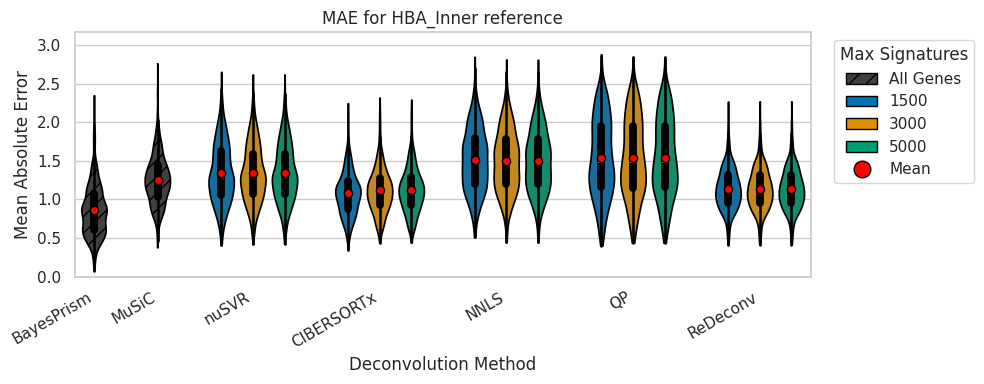

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
from matplotlib import rcParams
import matplotlib.ticker as mticker
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Load the data
df = pd.read_csv('merged_Results_Spillover_Random_v2C_New.txt', sep='\t')

# Extract reference and max genes from matrix names
df['Reference'] = df['Matrix'].apply(lambda x: "_".join(x.split('_')[:2]))
df['MaxGenes'] = df['Matrix'].apply(lambda x: x.split('_')[-2])

# --- Use colorblind palette as always
maxgenes_order = ['1500', '3000', '5000']
cb_palette = sns.color_palette("colorblind", n_colors=len(maxgenes_order))

# Create output directory
output_dir = 'Results_Spillover_Grouped'
os.makedirs(output_dir, exist_ok=True)

# --- Global font sizes (publication ready) ---
rcParams.update({
    "axes.titlesize": 13,     # plot title
    "axes.labelsize": 12,     # x/y labels
    "xtick.labelsize": 10,    # x tick labels
    "ytick.labelsize": 10,    # y tick labels
    "legend.title_fontsize": 11,
    "legend.fontsize": 10
})
sns.set(style="whitegrid")

SP = "__SP__"  # spacer prefix
ALL_GENES_COLOR = (0.25, 0.25, 0.25)  # dark grey for All Genes

for reference in df['Reference'].unique():
    subset = df[df['Reference'] == reference]

    special_methods = ['BayesPrism', 'MuSiC']
    normal_df = subset[~subset['Method'].isin(special_methods)].copy()
    special_df = subset[subset['Method'].isin(special_methods)].copy()

    methods = subset['Method'].unique().tolist()
    methods = [m for m in methods if m not in special_methods + ['nuSVR']]
    methods.sort()
    custom_order = [m for m in special_methods if m in subset['Method'].unique()]
    if 'nuSVR' in subset['Method'].unique():
        custom_order += ['nuSVR']
    custom_order += methods

    plt.figure(figsize=(10, 4))

    normal_df['XLabel'] = normal_df.apply(lambda r: f"{r['Method']}__{r['MaxGenes']}", axis=1)
    special_df['XLabel'] = special_df['Method']

    # --- order with an invisible spacer BEFORE the 500 violin of each normal method and before MuSiC
    x_order = []
    for m in custom_order:
        if m in special_methods:
            x_order.append(m)
            if m == "BayesPrism":
                x_order.append(f"{SP}{m}_to_MuSiC")  # spacer between special methods
        else:
            x_order.append(f"{SP}{m}")              # spacer before 500
            x_order += [f"{m}__{g}" for g in maxgenes_order]

    # palette (add transparent color for spacers)
    g2c = dict(zip(maxgenes_order, cb_palette))
    transparent = (0, 0, 0, 0)
    palette_map = {}
    for m in custom_order:
        if m in special_methods:
            palette_map[m] = ALL_GENES_COLOR
            if m == "BayesPrism":
                palette_map[f"{SP}{m}_to_MuSiC"] = transparent
        else:
            palette_map[f"{SP}{m}"] = transparent
            for g in maxgenes_order:
                palette_map[f"{m}__{g}"] = g2c[g]

    plot_df = pd.concat([normal_df, special_df], ignore_index=True)

    ax = sns.violinplot(
        data=plot_df,
        x='XLabel',
        y='Average_MAE',
        order=x_order,
        palette=palette_map,
        inner='box',
        density_norm='area',
        width=0.80,  # wide violins
        cut=0
    )

    # --- Apply hatch ONLY to the All Genes violins (BayesPrism, MuSiC)
    label_to_x = {lab: idx for idx, lab in enumerate(x_order)}
    special_x = {label_to_x[m] for m in ['BayesPrism', 'MuSiC'] if m in label_to_x}

    for coll in [c for c in ax.collections if hasattr(c, "get_paths")]:
        try:
            verts = coll.get_paths()[0].vertices
        except Exception:
            continue
        xmean = verts[:, 0].mean()
        if round(xmean) in special_x:
            coll.set_facecolor(ALL_GENES_COLOR)
            coll.set_hatch('//')
            coll.set_edgecolor('black')

    # center method labels (skip spacers)
    xticks, xticklabels = [], []
    for m in custom_order:
        if m in special_methods:
            pos = x_order.index(m)
            xticks.append(pos); xticklabels.append(m)
        else:
            trio = [x_order.index(f"{m}__{g}") for g in maxgenes_order]
            xticks.append(sum(trio)/len(trio)); xticklabels.append(m)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=30, ha='right')

    ymax = plot_df["Average_MAE"].max()
    ax.set_ylim(0, ymax * 1.1)
    ax.margins(x=0.01, y=0.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))

    # titles/labels (fonts already set via rcParams)
    ax.set_title(f"MAE for {reference} reference")
    ax.set_xlabel('Deconvolution Method')
    ax.set_ylabel('Mean Absolute Error')

    # legend + mean dots
    MEAN_DOT_SIZE = 35
    legend_handles = [
        Patch(facecolor=ALL_GENES_COLOR, edgecolor='black', hatch='//', label='All Genes')
    ]
    legend_handles += [Patch(facecolor=g2c[g], edgecolor='black', label=g) for g in maxgenes_order]

    means = plot_df.groupby('XLabel')['Average_MAE'].mean()
    for xpos, label in enumerate(x_order):
        if label.startswith(SP):
            continue
        if label in means:
            ax.scatter(xpos, means[label], color='red', s=MEAN_DOT_SIZE, zorder=3,
                       marker='o', edgecolor='black')

    legend_handles += [Line2D([0], [0], marker='o', color='red', label='Mean',
                              markerfacecolor='red', markeredgecolor='black',
                              markersize=12, linestyle='')]

    ax.legend(handles=legend_handles, title='Max Signatures',
              bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()

    fig = plt.gcf()  # get current figure
    filename = f'Violin_Random_{reference}_all_methods.svg'.replace(' ', '_')
    fig.savefig(os.path.join(output_dir, filename), bbox_inches="tight")
    plt.close(fig)
